# Bootstrap estimation

This notebook contains the code examples for the blog post
[???](???),
which explains how Python can help us better understand probability and statistics concepts. I've reproduced the essential parts of the narrative here (in abridged form) so the notebook should be readable on its own.

The benefit of the notebook version is you can play with the code examples interactively. To run a code cell, press the play button in the menu bar, or use the keyboard shortcut **SHIFT+ENTER**.

### Notebook setup

In [1]:
# Install stats library
%pip install --quiet ministats 


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Figures setup
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    style="whitegrid",
    rc={'figure.figsize': (6, 3)},
)
# High-resolution figures please
%config InlineBackend.figure_format = 'retina'

def savefig(fig, filename, **kwargs):
    fig.tight_layout(**kwargs)
    fig.savefig(filename, dpi=300, bbox_inches="tight", pad_inches=0)

<Figure size 640x480 with 0 Axes>

## Introduction

In notebook, I want to introduce you to some core statistics concepts from a computational perspective. By writing simple Python code (mostly `for` loops), you can understand some core ideas of statistics. If you're not familiar with Python at all, I recommend you read [Part 1 of the blog post series](https://minireference.com/blog/python-for-stats/) and consult [this notebook](./python_for_stats.ipynb) first.

**TL;DR** My main realization from working on this book is that the hands-on computational approach to statistical calculations makes learning concepts much more straightforward, as compared to the classical way of teaching which is based on formulas and procedures. This is why we'll present the key ideas using Python code and visualizations, which should be accessible to most readers.


The statistical analyses examples in this notebook are taken from the textbook [No Bullshit Guide to Stats](https://nobsstats.com/), which you can check out if you want to learn more statistics.

Let's start with what this is all about…

### The modern statistics curriculum

Many statistics techniques of the classical curriculum were developed in a time with limited computation capabilities. Using a computational approach makes many  "hard" topics in statistics much easier to understand. There is a growing movement in statistics education called "modern statistics" that puts the focus on using computers for statistical calculations.

The two techniques from the modern statistics curriculum we'll discuss in this blog post are:
- **Simulation**: Direct computational approach for doing probability calculations by simulating tens of thousands of samples from the relevant population. We can then calculate relevant quantities directly from the samples instead of using math formulas. 
- **Resampling methods**: This is an umbrella term for various clever techniques that reuse data from observed sample to simulate the variability in the population.

The simulation and resampling methods are computationally expensive, but they apply for **any distribution** and allows us to compute **any quantity of interest**—not just quantities for which statisticians have found formulas.

### Bootstrap estimation

The bootstrap procedure is a powerful technique for estimating the variability of any estimator. 

Computationally, the bootstrap method involves a simple for-loop that repeatedly generates new samples from the existing data. This approach to uncertainty estimation is very intuitive, and it allows us to reach a deeper understanding, instead of the usual analytical approximation methods that are traditionally taught in STATS101.

## Example data analysis scenario

We'll use an example to ground the discussions in the rest of the notebook. 

### IQ scores population

In [3]:
from scipy.stats import norm

cohen_d = 0.55
muX = 100 + cohen_d*15
rvX = norm(loc=muX, scale=15)
print(f"N(mu={muX},sigma=15)")

N(mu=108.25,sigma=15)


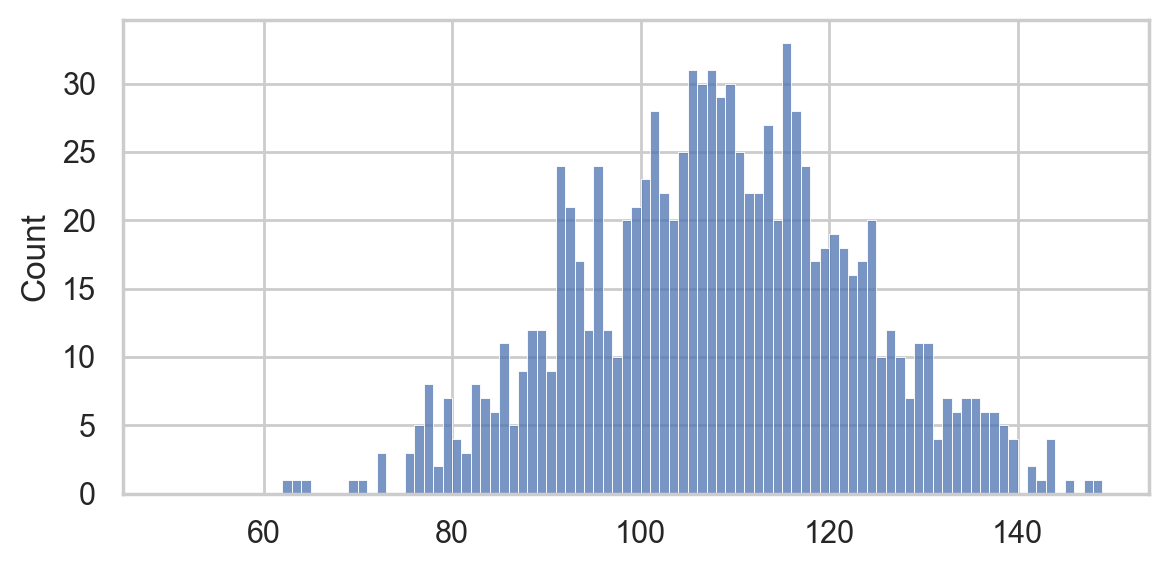

In [4]:
import numpy as np
np.random.seed(43)

N = 1000
iqs_pop = rvX.rvs(N)
sns.histplot(iqs_pop, bins=range(50,150,1))

savefig(plt.gcf(), "figures/histplot_iqs_pop.png");

### IQ scores sample

Consider the following dataset,
which consists of IQ scores of 30 students who took a "smart drug" ☕.
The IQ scores are recorded in the following list.

In [5]:
iqs = [ 95.7, 100.1,  95.3, 100.7, 123.5, 119.4,  84.4, 109.6,
       108.7,  84.7, 111.0,  92.1, 138.4, 105.2,  97.5, 115.9,
       104.4, 105.6, 104.8, 110.8,  93.8, 106.6,  71.3, 130.6,
       125.7, 130.2, 101.2, 109.0, 103.8,  96.7]

In [6]:
# sample size (n)
len(iqs)

30

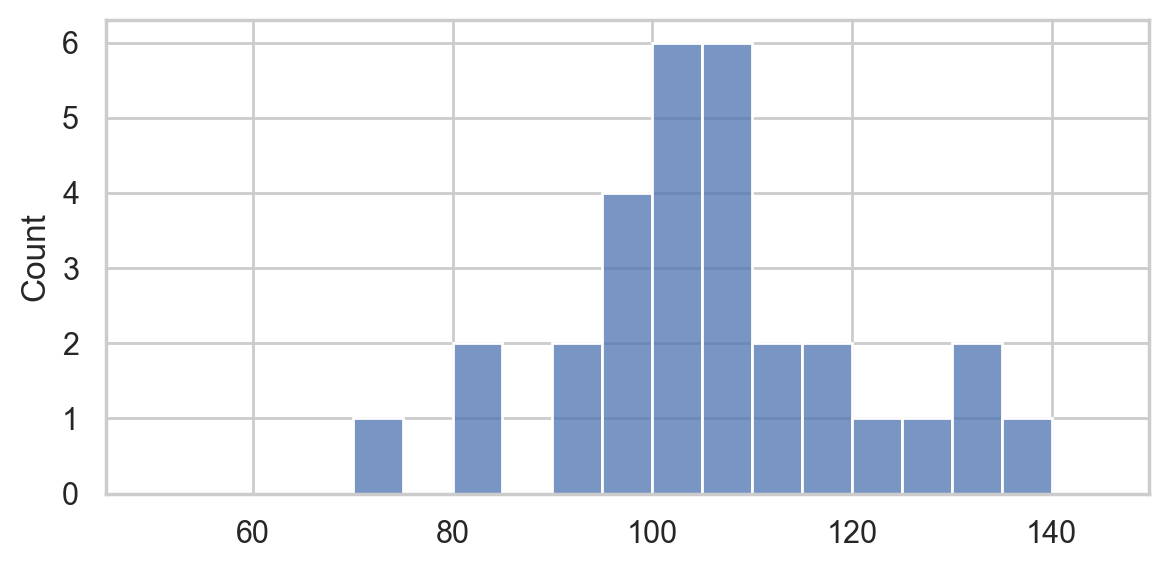

In [7]:
import seaborn as sns
sns.histplot(iqs, bins=range(50,150,5));

savefig(plt.gcf(), "figures/histplot_iqs.png")

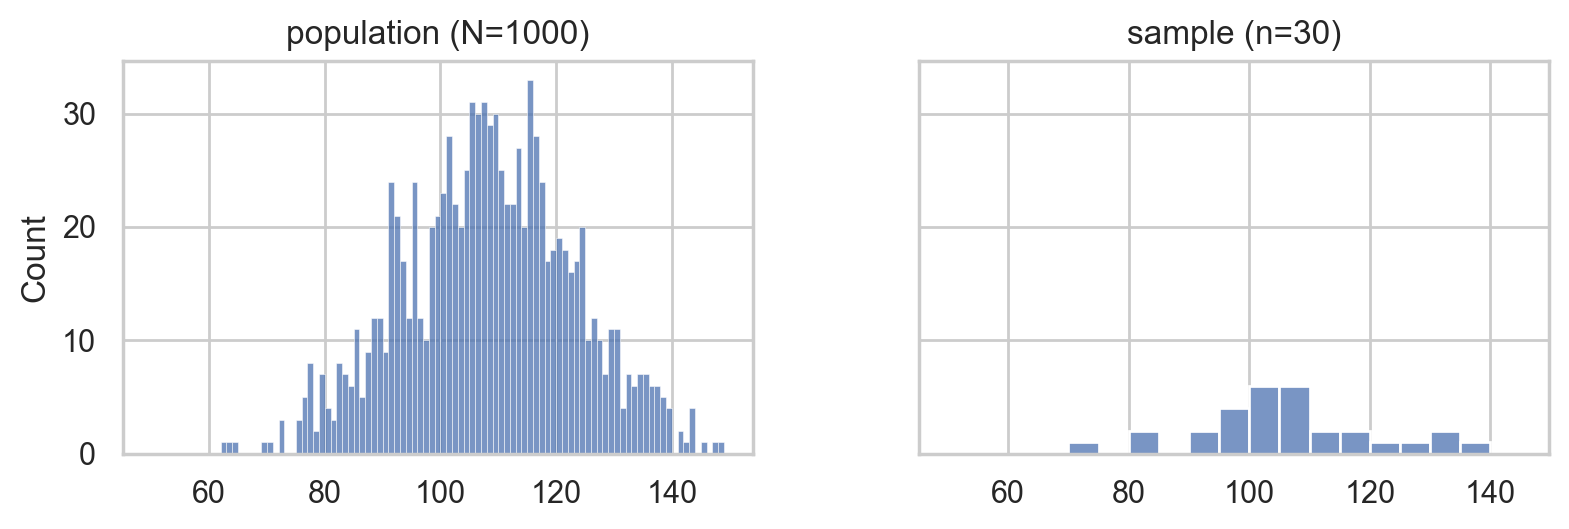

In [8]:
with plt.rc_context({"figure.figsize":(8,2.8)}):

    fig, (ax1,ax2) = plt.subplots(1,2, sharey=True)
    
    sns.histplot(iqs_pop, bins=np.arange(50,150,1), ax=ax1)
    ax1.set_title("population (N=1000)")
    
    sns.histplot(iqs, bins=range(50,150,5), ax=ax2)
    ax2.set_title("sample (n=30)")
    
    savefig(plt.gcf(), "figures/histplots_iqs_pop_and_sample.png", w_pad=5)

### Descriptive statistics

In [9]:
from statistics import mean
mean(iqs)

105.89

In [10]:
from statistics import stdev as std
std(iqs)

14.658229417469641

### Statistical inference by eyeball

Move the sliders to choose the model parameters that best match the data.

In [11]:
import numpy as np
from scipy.stats import norm
from ipywidgets import interact

def plot_pop_and_sample(mu, sigma):
    # 1. Plot histogram of sample
    ax = sns.histplot(x=iqs, stat="density", bins=range(50,150,5), label="data")
    # 2. Plot probability density function of population model
    rvX = norm(mu, sigma)
    xs = np.linspace(50, 150, 1000)
    fXs = rvX.pdf(xs)
    sns.lineplot(x=xs, y=fXs, ax=ax, c="C0", label="model")
    print(f"current population model guess: X ~ N(mu={mu}, sigma={sigma})")

interact(plot_pop_and_sample, mu=(50,150,1), sigma=(3,40,1));

interactive(children=(IntSlider(value=100, description='mu', max=150, min=50), IntSlider(value=21, description…

## Bootstrap estimation

TODO: import from blog post and slides

Generate 5000 bootstrap samples (sampling with replacement) from the sample `iqs`.
Use the bootstrap samples to approximate the sampling distribution of the mean.

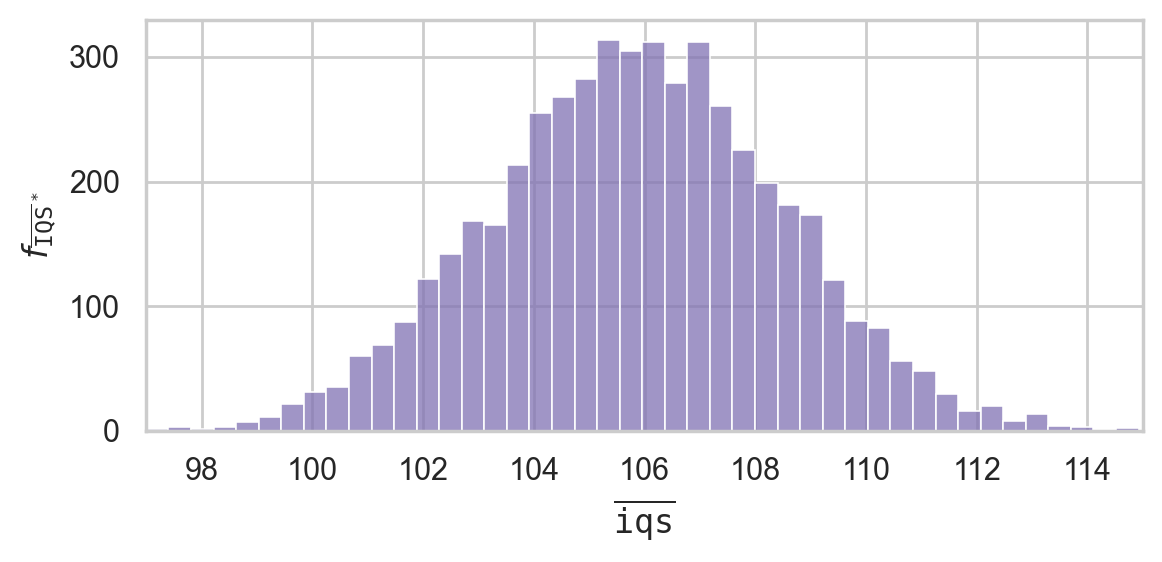

In [12]:
np.random.seed(46)

n = 30    # sample size
B = 5000  # number of bootstrap samples

bmeans = []
for i in range(0, B):
    bsample = np.random.choice(iqs, n, replace=True)
    bmean = mean(bsample)
    bmeans.append(bmean)

ax = sns.histplot(bmeans, color="C4")
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs.png")

In [13]:
ci90 = np.percentile(bmeans, [5, 95])
ci90.round(2)

array([101.52, 110.16])

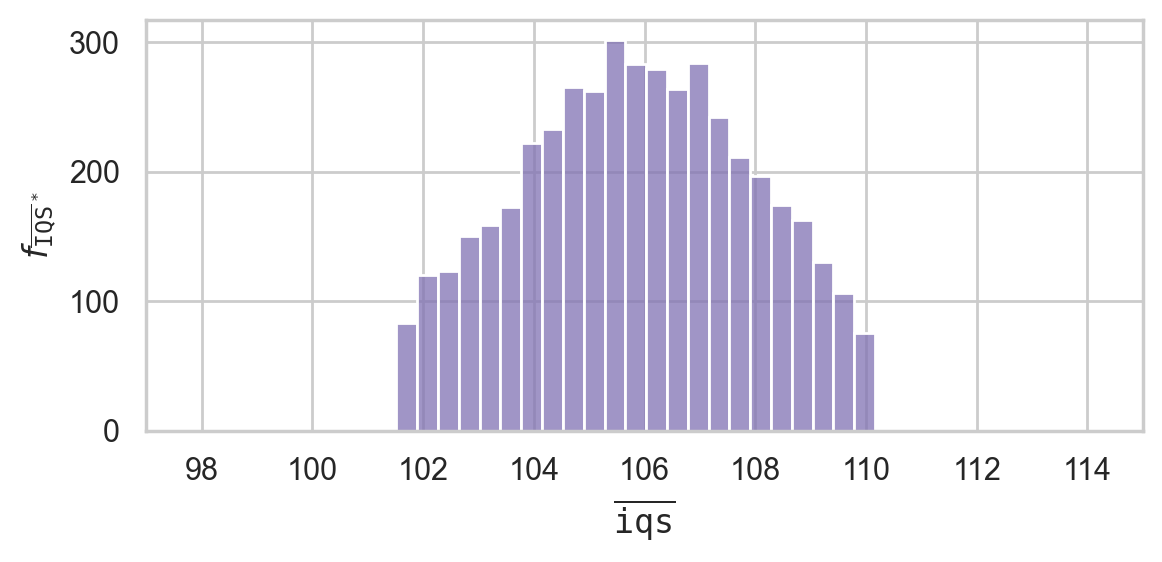

In [14]:
bulk = [x for x in bmeans if x > ci90[0] and x < ci90[1]]
ax = sns.histplot(bulk, color="C4")
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs_ci.png")

#### Alternative using formula

In [15]:
from ministats import ci_mean
ci_mean(iqs, alpha=0.1)

[101.34277195122348, 110.43722804877652]

## Conclusion

## Links

- [Python tutorial](https://nobsstats.com/tutorials/python_tutorial.html)
- Previous blog posts:
  - [Outline of the stats curriculum research](https://minireference.com/blog/fixing-the-introductory-statistics-curriculum/)
  - [Book proposal](https://minireference.com/blog/no-bullshit-guide-to-statistics-progress-update/)
  - [Stats survey results](https://minireference.com/blog/what-stats-do-people-want-to-learn/)
  - [Python coding skills for statistics](https://minireference.com/blog/python-for-stats/)
- Book website [noBSstats.com](https://nobsstats.com/intro.html): contains all the notebooks, demos, and visualizations from the book.
- Great talks on resampling methods:
  - [Statistics for Hackers](https://www.youtube.com/watch?v=Iq9DzN6mvYA) talk by Jake Vanderplas
  - [There's Only One Test](https://www.youtube.com/watch?v=S41zQEshs5k) talk by Allen B. Downey

<!-- 
- [Detailed book outline](https://docs.google.com/document/d/1fwep23-95U-w1QMPU31nOvUnUXE2X3s_Dbk5JuLlKAY/edit): continuously updated list of the topics that are covered in each section.
- [Pandas tutorial](https://nobsstats.com/tutorials/pandas_tutorial.html)
- [Seaborn tutorial](https://nobsstats.com/tutorials/seaborn_tutorial.html)
-->
